# Compressed Image Classification
In this notebook, a Image Classification model is implemented, analyzing its performance over a dataset of compressed images. The aim of the experiment is to try to make a prediction model able to classify images, starting from their compressed representation.

The idea is to use the ResNet50 model (the same used as baseline on raw images dataset), modifying it according to the new input size.
In this case, the input size consists of a single channel as input.

In [1]:
import matplotlib.pyplot as plt
import torch

# setup the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. The dataset

The CIFAR-10 dataset is a collection of images that are used to train machine learning and computer vision algorithms. It consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

The compressed version is obtained through the Generalized Deduplication (GD) approach. After the compression, each file has been elaborated to provide a proper shape as input for the network.

For each image, the output of the algorithm is a single channel, with 224x224 values.
Each of them is obtained by:

$$ z_i = r_i + c_i $$
Where $c_j$ is:
$$ c_i=∑δ_j $$
and $δ_j$ is:
$$ δ_i=⌊S∙\frac{log_2⁡〖(∆_i+1)〗}{log_2⁡〖(∆_max+1)〗}⌋ $$

### 1.1 Dataset Download
The notebook is run (by now) on Google Colab, so the dataset can be retrieved from Google Drive

In [2]:
from pathlib import Path
from zipfile import ZipFile
import json
import shutil

LOCAL = True # set False if you want to run the code in Google Colab

if LOCAL:
    DATA_ROOT = Path("../output")
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_ROOT = DATA_ROOT
    VERSION_ROOT = DATA_ROOT / "v2_cumulative_rank-s2"

else:
    from google.colab import drive

    drive.mount('/content/drive')

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "AARHUS INTERNSHIP/v2_cumulative_rank_s1"
    )
    DATA_ROOT = Path("/content/cifar10_v2")
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    for split in ("train", "test"):
        folder = DATA_ROOT / split
        folder.mkdir(exist_ok=True)

        source_manifest = DRIVE_ROOT / f"manifest_{split}.json"
        manifest = json.loads(source_manifest.read_text(encoding="utf-8"))
        expected = {sample["file"] for sample in manifest["samples"]}

        if any("/" in name or "\\" in name for name in expected):
            raise ValueError("Il manifest contiene sottocartelle: adattare i percorsi.")

        missing = [
            name for name in expected
            if not (folder / name).is_file()
        ]

        if missing:
            local_zip = DATA_ROOT / f"{split}.zip"
            shutil.copy2(DRIVE_ROOT / f"{split}.zip", local_zip)

            with ZipFile(local_zip) as archive:
                members = {}

                for member in archive.infolist():
                    if member.is_dir() or not member.filename.endswith(".npz"):
                        continue

                    name = member.filename.replace("\\", "/").rsplit("/", 1)[-1]

                    if name in members:
                        raise ValueError(f"Nome duplicato nello ZIP: {name}")

                    members[name] = member

                absent = expected - members.keys()
                if absent:
                    raise ValueError(
                        f"{split}: {len(absent)} file del manifest assenti nello ZIP."
                    )

                for index, name in enumerate(missing, 1):
                    destination = folder / name
                    temporary = destination.with_suffix(".npz.part")

                    with archive.open(members[name]) as source:
                        with temporary.open("wb") as target:
                            shutil.copyfileobj(source, target)

                    temporary.replace(destination)

                    if index % 5000 == 0 or index == len(missing):
                        print(f"{split}: extracted {index}/{len(missing)} file")

            # Delete compressed file from the local session memory
            local_zip.unlink()

        shutil.copy2(source_manifest, folder / f"manifest_{split}.json")
        print(f"{split}: {len(expected)} samples")

This version allows to upload a subsample, just for check the logic and proper working of the code:

In [3]:
# Optional override. Leave False to use the full dataset prepared above.
USE_SUBSAMPLE = False
if USE_SUBSAMPLE:
    DATA_ROOT = DRIVE_ROOT / "subsample"
print("Dataset root:", DATA_ROOT)


Dataset root: ..\output


### 1.2 Upload all the dataset into variables
The class `CumulativeDataset()` allows to obtain the pairs (image,label) merging the information from the compressed images and the json containing the label details

In [16]:
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class CumulativeDataset(Dataset):
    def __init__(self, manifest_path, transform=None):
        self.manifest_path = Path(manifest_path)
        self.folder = self.manifest_path.parent
        self.transform = transform

        with self.manifest_path.open(encoding="utf-8") as f:
            manifest = json.load(f)

        self.samples = manifest["samples"]
        self.idx_to_class = {
            index: name
            for name, index in manifest["class_to_idx"].items()
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        with np.load(
            self.folder / sample["file"],
            allow_pickle=False
        ) as data:
            array = data["z_u16"].astype(np.float32)

        image = torch.from_numpy(array).unsqueeze(0)
        # shape: [1, 224, 224]

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, label

In [22]:
# Statistics use ONLY the training manifest, before random augmentation.
# CumulativeDataset already returns float32 tensors [1, 224, 224] in raw z units.
import hashlib
import json
import numpy as np
import torchvision.transforms as transforms

def find_manifest(folder, split):
    candidates = [folder / f"manifest_{split}.json", 
                  folder / "manifest.json",
                  folder / f"subsample_manifest_{split}.json"]
    found = [path for path in candidates if path.exists()]
    if len(found) != 1:
        raise ValueError(f"Expected one manifest in {folder}, found {found}")
    return found[0]
if LOCAL:
    TRAIN_MANIFEST = find_manifest(VERSION_ROOT / "train", "train")
    TEST_MANIFEST = find_manifest(VERSION_ROOT / "test", "test")
    STATS_PATH = VERSION_ROOT / "normalization_z_u16.json"
else:
    TRAIN_MANIFEST = find_manifest(DATA_ROOT, "train")
    TEST_MANIFEST = find_manifest(DATA_ROOT, "test")
    STATS_PATH = DRIVE_ROOT / ("normalization_subsample_z_u16.json" if USE_SUBSAMPLE
                           else "normalization_full_train_z_u16.json")

FORCE_RECOMPUTE_STATS = True  # Set True after replacing data while preserving file timestamps.

def training_stats(manifest_path, cache_path, force=False):
    """Compute mean and variance on the training set, if they didn't exist yet. If so, it load them"""
    manifest_bytes = manifest_path.read_bytes()
    manifest = json.loads(manifest_bytes)
    if manifest.get("split") != "train":
        raise ValueError("Normalization statistics must come from the training split.")
    samples = manifest["samples"]
    if not samples:
        raise ValueError("The training manifest is empty.")
    filenames = [sample["file"] for sample in samples]
    if len(set(filenames)) != len(filenames):
        raise ValueError("Duplicate files in the training manifest.")

    # Invalidate cache when the manifest, file size, or modification time changes.
    # This avoids re-reading all arrays when re-running the notebook.
    signature = hashlib.sha256(b"z_u16-raw-224x224-population-std-v1\n")
    signature.update(manifest_bytes)
    if LOCAL:
        paths = [VERSION_ROOT / "train" / filename for filename in filenames]
    else:
        paths = [manifest_path.parent / filename for filename in filenames]
    for path in paths:
        stat = path.stat()
        signature.update(f"{path.name}:{stat.st_size}:{stat.st_mtime_ns}\n".encode())
    fingerprint = signature.hexdigest()

    if cache_path.exists() and not force:
        cached = json.loads(cache_path.read_text(encoding="utf-8"))
        if cached.get("fingerprint") == fingerprint:
            if not np.isfinite(cached["mean"]) or not np.isfinite(cached["std"]) or cached["std"] <= 0:
                raise ValueError("Invalid cached statistics; set FORCE_RECOMPUTE_STATS=True.")
            print(f"Loaded training statistics from {cache_path}")
            return cached

    # Merge per-image moments in float64: global population std, not the
    # average of image standard deviations. Only one image is held at a time.
    count, mean, m2 = 0, 0.0, 0.0
    for index, path in enumerate(paths, 1):
        with np.load(path, allow_pickle=False) as archive:
            z = archive["z_u16"]
            if z.dtype != np.uint16 or z.shape != (224, 224):
                raise ValueError(f"Expected uint16 [224,224]: {path}, got {z.dtype} {z.shape}")
            values = z.astype(np.float64)
        n = values.size
        image_mean = float(values.mean())
        image_m2 = float(np.square(values - image_mean).sum())
        new_count = count + n
        delta = image_mean - mean
        m2 += image_m2 + delta * delta * count * n / new_count
        mean += delta * n / new_count
        count = new_count
        if index % 5000 == 0 or index == len(paths):
            print(f"Training statistics: {index}/{len(paths)} images")

    std = float(np.sqrt(m2 / count))
    if not np.isfinite(std) or std <= 0:
        raise ValueError("Training standard deviation is zero or non-finite.")
    stats = dict(schema="z_u16-normalization-v1", fingerprint=fingerprint,
                 training_manifest=manifest_path.name, num_images=len(paths),
                 num_pixels=count, mean=float(mean), std=std,
                 units="raw z_u16 values; no division by 65535", ddof=0)
    temporary = cache_path.with_suffix(".json.tmp")
    temporary.write_text(json.dumps(stats, indent=2) + "\n", encoding="utf-8")
    temporary.replace(cache_path)
    print(f"Saved training statistics to {cache_path}")
    return stats


normalization_stats = training_stats(
    TRAIN_MANIFEST, STATS_PATH, force=FORCE_RECOMPUTE_STATS
)
CHANNEL_MEAN = normalization_stats["mean"]
CHANNEL_STD = normalization_stats["std"]
print(f"Training mean={CHANNEL_MEAN:.6f}, std={CHANNEL_STD:.6f} (raw z units)")

# Inputs are already tensors and 224x224; Resize is normally a no-op.
# Do not add ToTensor() or divide by 65535: the statistics are in raw z units.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Normalize(mean=[CHANNEL_MEAN], std=[CHANNEL_STD]),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[CHANNEL_MEAN], std=[CHANNEL_STD]),
])


Training statistics: 5000/50000 images
Training statistics: 10000/50000 images
Training statistics: 15000/50000 images
Training statistics: 20000/50000 images
Training statistics: 25000/50000 images
Training statistics: 30000/50000 images
Training statistics: 35000/50000 images
Training statistics: 40000/50000 images
Training statistics: 45000/50000 images
Training statistics: 50000/50000 images
Saved training statistics to ..\output\v2_cumulative_rank-s2\normalization_z_u16.json
Training mean=1524.683301, std=2870.027249 (raw z units)


In [23]:
train_data = CumulativeDataset(TRAIN_MANIFEST, transform=train_transform) 
test_data = CumulativeDataset(TEST_MANIFEST, transform=test_transform)
assert train_data.idx_to_class == test_data.idx_to_class
print(f"Training samples: {len(train_data)}; test samples: {len(test_data)}")


Training samples: 50000; test samples: 10000


#2. Batches generation and check their validity

In [30]:
BATCH_SIZE = 32
train_generator = torch.Generator().manual_seed(2)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          generator=train_generator, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_loader)} batches; test: {len(test_loader)} batches")


Train: 1563 batches; test: 313 batches


Images: torch.Size([32, 1, 224, 224]); labels: torch.Size([32])


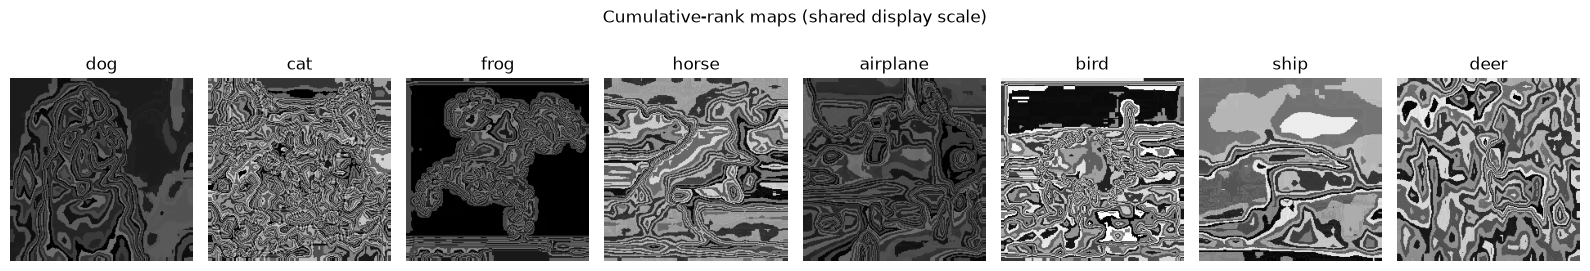

In [32]:

x, y = next(iter(train_loader))
print(f"Images: {x.shape}; labels: {y.shape}")
# These are feature maps, not reconstructed RGB images.
raw_maps = x * CHANNEL_STD + CHANNEL_MEAN
count = min(8, len(raw_maps))
fig, axes = plt.subplots(1, count, figsize=(2 * count, 3), squeeze=False)
vmax = max(float(raw_maps[:count].max()), 1.0)
for i, axis in enumerate(axes[0]):
    axis.imshow(raw_maps[i, 0].numpy(), cmap="gray", vmin=0, vmax=vmax)
    axis.set_title(train_data.idx_to_class[y[i].item()])
    axis.axis("off")
fig.suptitle("Cumulative-rank maps (shared display scale)")
plt.tight_layout()
plt.show()


Check batch validity:

In [33]:
images, labels = next(iter(train_loader))

print(images.shape)  # torch.Size([32, 1, 224, 224])
print(images.dtype)  # torch.float32

print(labels.shape) # torch.Size([32])
print(labels.dtype) # torch.int64
print(labels[:5])

print([
    train_data.idx_to_class[label.item()]
    for label in labels[:5]
])

torch.Size([32, 1, 224, 224])
torch.float32
torch.Size([32])
torch.int64
tensor([8, 6, 2, 8, 1])
['ship', 'frog', 'bird', 'ship', 'automobile']


# 3. The Model: Pre-Trained ResNet50
In a first try, the ResNet50 model is used. At first, only a fine tuning of the first and the last layers, for make the size compatible, is made

### Custom ResNet50 for single-channel input + additional features

We need to define a custom ResNet50 class that extends `torchvision.models.ResNet` to:

1.  **Modify the first convolutional layer (`conv1`)**: Change its `in_channels` from 3 (for RGB) to 1 (for `rank_cumulative_delta` channel). When loading pre-trained weights, we'll exclude the original `conv1` weights and initialize the new `conv1` layer.
2.  **Modify the final fully connected layer (`fc`)**: Edited to provide classification over the 10 classes.

In [34]:
import torchvision.models as models
import torch.nn as nn

class CustomResNet50(models.ResNet):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__(models.resnet.Bottleneck, [3, 4, 6, 3], num_classes=num_classes)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            weights = models.ResNet50_Weights.IMAGENET1K_V1
            state = weights.get_state_dict(progress=True)
            state = {k: v for k, v in state.items()
                     if not (k.startswith("conv1.") or k.startswith("fc."))}
            self.load_state_dict(state, strict=False)
        nn.init.kaiming_normal_(self.conv1.weight, mode="fan_out", nonlinearity="relu")
        # Preserve the chosen experiment: train only the new conv1 and fc.
        for parameter in self.parameters():
            parameter.requires_grad = False
        for layer in (self.conv1, self.fc):
            for parameter in layer.parameters():
                parameter.requires_grad = True

    def train(self, mode=True):
        super().train(mode)
        # requires_grad=False does not freeze BatchNorm running statistics.
        # Keep the frozen backbone statistics fixed as well.
        for module in self.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        return self
    # Inherit ResNet.forward: it already supports the replaced one-channel conv1.


In [35]:
# Run once for a new experiment OR to restore a checkpoint.
# Do not rerun this cell when merely adding epochs in the current session.
from pathlib import Path
import math

MODELS_DIR = Path("/content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/models")
CHECKPOINT_TO_LOAD = None  # Example: MODELS_DIR / "v2_S1_2026-10-06_14-30-00-123456.pth"
INITIAL_LR = 0.1
torch.manual_seed(42)

checkpoint = None
if CHECKPOINT_TO_LOAD is not None:
    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location="cpu", weights_only=True)
    if checkpoint.get("representation") != "cumulative-rank-u16-v1" or checkpoint.get("scale") != 1:
        raise ValueError("Expected a v2 S=1 checkpoint created by this notebook.")
    if checkpoint["idx_to_class"] != train_data.idx_to_class:
        raise ValueError("Checkpoint class mapping differs from the current dataset.")
    for key, current in (("mean", CHANNEL_MEAN), ("std", CHANNEL_STD)):
        if not math.isclose(checkpoint["normalization"][key], current, rel_tol=1e-9):
            raise ValueError("Normalization differs: select the same dataset/statistics before resuming.")

resnet_single_channel = CustomResNet50(num_classes=10, pretrained=checkpoint is None).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    (p for p in resnet_single_channel.parameters() if p.requires_grad), lr=INITIAL_LR
)
history = []
test_metrics = None
if checkpoint is not None:
    resnet_single_channel.load_state_dict(checkpoint["model_state_dict"], strict=True)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    history = checkpoint["history"]
    if checkpoint["completed_epochs"] != len(history):
        raise ValueError("Checkpoint epoch count and history disagree.")
    test_metrics = checkpoint.get("test_metrics")

print("Completed epochs:", len(history))
print("Total parameters:", sum(p.numel() for p in resnet_single_channel.parameters()))
print("Trainable parameters:", sum(p.numel() for p in resnet_single_channel.parameters() if p.requires_grad))
resnet_single_channel.eval()
with torch.inference_mode():
    check_logits = resnet_single_channel(images[:2].to(device))
assert check_logits.shape == (min(2, len(images)), 10)
assert torch.isfinite(check_logits).all()
if checkpoint is not None:
    torch.set_rng_state(checkpoint["torch_rng_state"])
    train_generator.set_state(checkpoint["loader_rng_state"])
    if torch.cuda.is_available() and checkpoint.get("cuda_rng_states"):
        if len(checkpoint["cuda_rng_states"]) == torch.cuda.device_count():
            torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])
print("Model ready. Run the single training cell to add epochs.")


Completed epochs: 0
Total parameters: 23522250
Trainable parameters: 23626
Model ready. Run the single training cell to add epochs.


# 4. Functions
Some functions helpful for repeated workflows

### 4.1 Training and testing

In [36]:
def train_step(model, data_loader, loss_fn, optimizer, device=device):
    model.to(device)
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        # CrossEntropyLoss uses the batch mean; weight it by actual batch size.
        batch_size = y.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == y).sum().item()
        count += batch_size
    if count == 0:
        raise ValueError("Empty training loader")
    metrics = {"loss": loss_sum / count, "accuracy": 100.0 * correct / count}
    print(f"Train loss: {metrics['loss']:.5f} | Train accuracy: {metrics['accuracy']:.2f}%")
    return metrics


def test_step(model, data_loader, loss_fn, device=device):
    model.to(device)
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.inference_mode():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += loss_fn(logits, y).item() * y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            count += y.size(0)
    if count == 0:
        raise ValueError("Empty test loader")
    metrics = {"loss": loss_sum / count, "accuracy": 100.0 * correct / count}
    print(f"Test loss: {metrics['loss']:.5f} | Test accuracy: {metrics['accuracy']:.2f}%")
    return metrics


### 4.2 Timing function

In [37]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    # device ([type], optional): Device that compute is running on. Defaults to None.

    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 4.3 Accuracy Function


In [38]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# 5. Training and Test loops


In [39]:
# SINGLE TRAINING LOOP: every execution adds ADDITIONAL_EPOCHS.
# Keep the existing model, optimizer and history; no reset here.
from tqdm.auto import tqdm
from timeit import default_timer as timer

ADDITIONAL_EPOCHS = 5
if not isinstance(ADDITIONAL_EPOCHS, int) or ADDITIONAL_EPOCHS < 1:
    raise ValueError("ADDITIONAL_EPOCHS must be a positive integer")
start_epoch = len(history)
end_epoch = start_epoch + ADDITIONAL_EPOCHS
start_time = timer()
test_metrics = None  # Any previous test result refers to older weights.
for epoch in tqdm(range(start_epoch + 1, end_epoch + 1)):
    print(f"\nEpoch {epoch}/{end_epoch}")
    metrics = train_step(resnet_single_channel, train_loader, loss_fn, optimizer, device)
    history.append({"epoch": epoch, "loss": float(metrics["loss"]),
                    "accuracy": float(metrics["accuracy"]),
                    "lr": float(optimizer.param_groups[0]["lr"])})
print(f"Completed epochs: {len(history)}; elapsed: {timer() - start_time:.1f}s")
# Fixed learning rate: the held-out test does not guide training.


  0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/5
Train loss: 2.34904 | Train accuracy: 18.53%

Epoch 2/5
Train loss: 2.13090 | Train accuracy: 24.46%

Epoch 3/5
Train loss: 2.04131 | Train accuracy: 27.95%

Epoch 4/5
Train loss: 1.96514 | Train accuracy: 30.81%

Epoch 5/5
Train loss: 1.91572 | Train accuracy: 32.78%
Completed epochs: 5; elapsed: 1552.7s


Plot the behavior of the training loss function and the training accuracy

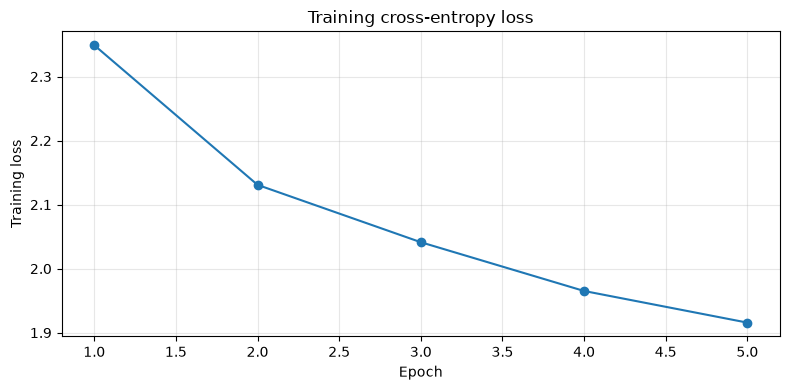

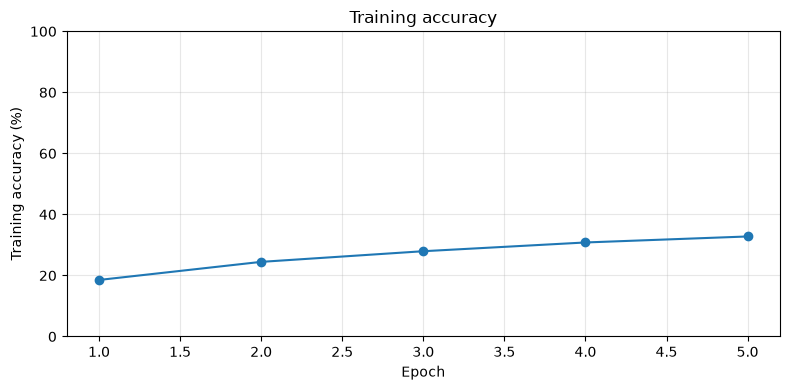

In [40]:
# Learning curves over ALL completed epochs, including restored history.
if not history:
    raise ValueError("Train or load a checkpoint with history first.")
epoch_numbers = [entry["epoch"] for entry in history]
fig_loss, ax_loss = plt.subplots(figsize=(8, 4))
ax_loss.plot(epoch_numbers, [entry["loss"] for entry in history], marker="o")
ax_loss.set(xlabel="Epoch", ylabel="Training loss", title="Training cross-entropy loss")
ax_loss.grid(alpha=0.3)
fig_loss.tight_layout()
plt.show()

fig_accuracy, ax_accuracy = plt.subplots(figsize=(8, 4))
ax_accuracy.plot(epoch_numbers, [entry["accuracy"] for entry in history], marker="o")
ax_accuracy.set(xlabel="Epoch", ylabel="Training accuracy (%)",
                title="Training accuracy", ylim=(0, 100))
ax_accuracy.grid(alpha=0.3)
fig_accuracy.tight_layout()
plt.show()


Compute prediction over the test set and plot a confusion matrix

Test loss: 2.01853; accuracy: 27.98%


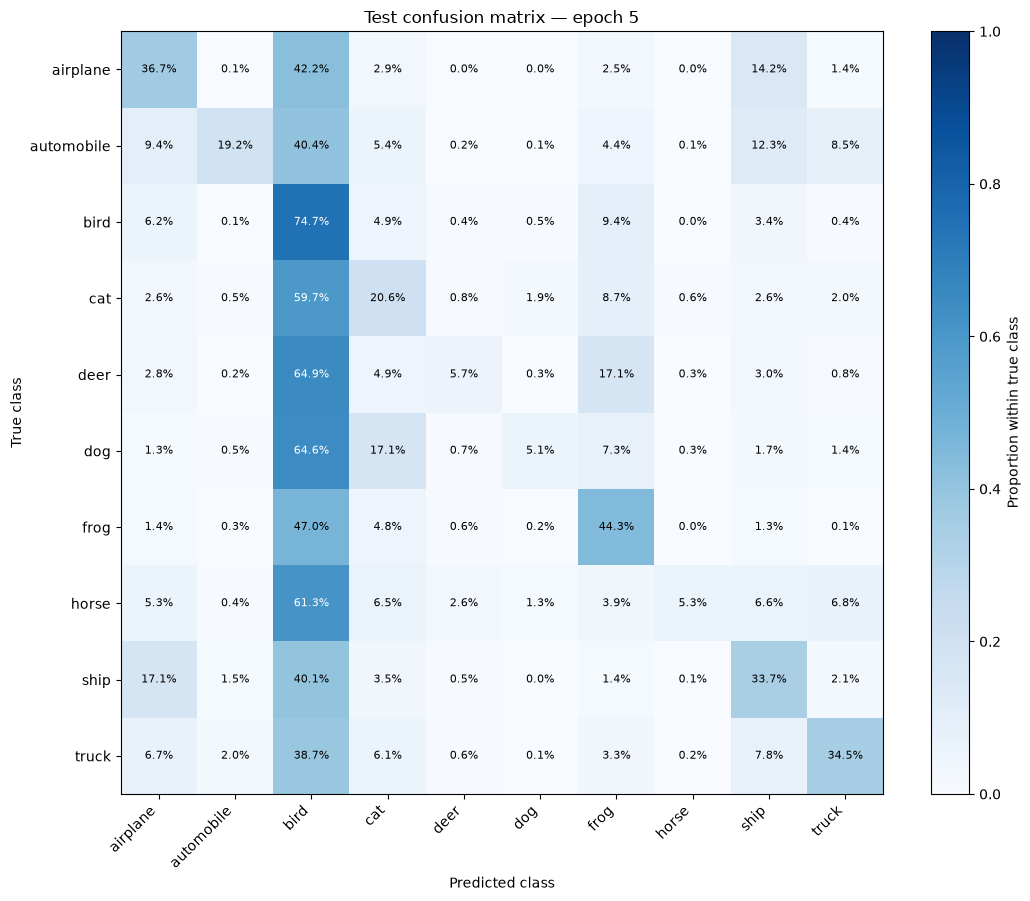

In [41]:
# Evaluate the current weights on test; do not use this to tune hyperparameters.
# Rows = true classes, columns = predicted classes. Each supported row sums to 1.
import numpy as np

num_classes = 10
class_names = [test_data.idx_to_class[i] for i in range(num_classes)]
confusion_counts = np.zeros((num_classes, num_classes), dtype=np.int64)
loss_sum, sample_count = 0.0, 0
resnet_single_channel.eval()
with torch.inference_mode():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet_single_channel(x)
        predictions = logits.argmax(dim=1)
        loss_sum += loss_fn(logits, y).item() * y.size(0)
        sample_count += y.size(0)
        pairs = (y * num_classes + predictions).cpu().numpy()
        confusion_counts += np.bincount(pairs, minlength=num_classes**2).reshape(num_classes, num_classes)
if sample_count == 0:
    raise ValueError("Empty test loader")
support = confusion_counts.sum(axis=1, keepdims=True)
confusion_proportions = np.divide(confusion_counts, support,
    out=np.zeros_like(confusion_counts, dtype=np.float64), where=support != 0)
test_metrics = {"epoch": len(history), "loss": loss_sum / sample_count,
    "accuracy": 100.0 * float(np.trace(confusion_counts)) / sample_count,
    "confusion_counts": confusion_counts.tolist(),
    "confusion_proportions": confusion_proportions.tolist()}
print(f"Test loss: {test_metrics['loss']:.5f}; accuracy: {test_metrics['accuracy']:.2f}%")
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(confusion_proportions, cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="Proportion within true class")
ax.set(xticks=range(num_classes), yticks=range(num_classes),
       xticklabels=class_names, yticklabels=class_names,
       xlabel="Predicted class", ylabel="True class",
       title=f"Test confusion matrix — epoch {len(history)}")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
for i in range(num_classes):
    for j in range(num_classes):
        value = confusion_proportions[i, j]
        label = f"{value:.1%}" if support[i, 0] else "N/A"
        ax.text(j, i, label, ha="center", va="center",
                color="white" if value > 0.5 else "black", fontsize=8)
fig.tight_layout()
plt.show()
# Diagonal = recall per class. N/A means that class is absent from this split.


# 6. Save and load the model
What we save of a model are its weights. So, when we load it back, we should create an instance of the model and set its weights with what we saved

In [42]:
# SAVE DIRECTLY TO DRIVE. Reuse this cell after any additional training.
from datetime import datetime
from zoneinfo import ZoneInfo
MODELS_DIR = Path("../output/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
date = datetime.now(ZoneInfo("Europe/Rome")).strftime("%Y-%m-%d_%H-%M-%S-%f")
MODEL_SAVE_PATH = MODELS_DIR / f"v2_S1_{date}.pth"
checkpoint_to_save = {
    "schema": "resnet-single-channel-checkpoint-v2",
    "representation": "cumulative-rank-u16-v2", "scale": 1,
    "model_state_dict": resnet_single_channel.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(), "num_classes": 10,
    "completed_epochs": len(history), "history": history,
    "normalization": normalization_stats, "idx_to_class": train_data.idx_to_class,
    "train_manifest": str(TRAIN_MANIFEST), "test_manifest": str(TEST_MANIFEST),
    "test_metrics": test_metrics,
    "torch_rng_state": torch.get_rng_state(),
    "loader_rng_state": train_generator.get_state(),
    "cuda_rng_states": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [],
}
# Exclusive creation prevents accidentally replacing a previous checkpoint.
with MODEL_SAVE_PATH.open("xb") as destination:
    torch.save(checkpoint_to_save, destination)
print(f"Saved {len(history)} completed epochs to {MODEL_SAVE_PATH}")


Saved 5 completed epochs to ..\output\models\v2_S1_2026-10-07_16-44-52-159970.pth


### Load the model from Google Drive

To restore in a new session:
 1. Prepare data, normalization and the CustomResNet50 class.
 2. In the initialization cell, set CHECKPOINT_TO_LOAD to the desired .pth path.
 3. Execute that cell: it restores resnet_single_channel, optimizer and history.
 4. Execute the training cell to add epochs, or the confusion-matrix cell to evaluate.
 
Do not run a second model initialization after restoring.
